# Actividad 1.3 — Carga y Exploración Básica de Datos
**Curso:** Ciencia de Datos | **Semana 1**

En este cuaderno practicamos la carga de datos con Pandas y la visualización básica con Matplotlib y Seaborn.

## 1. Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)

print('✅ Librerías importadas correctamente')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__} | Seaborn {sns.__version__}')

✅ Librerías importadas correctamente
   NumPy 2.4.2 | Pandas 3.0.1 | Seaborn 0.13.2


## 2. Crear un dataset de ejemplo

Simulamos un dataset de **calificaciones de estudiantes** con 5 variables.

In [2]:
np.random.seed(42)  # Para reproducibilidad

n = 80  # número de estudiantes

data = {
    'estudiante_id': range(1, n + 1),
    'nombre':        [f'Estudiante_{i}' for i in range(1, n + 1)],
    'matematicas':   np.random.normal(loc=7.5, scale=1.5, size=n).clip(0, 10).round(1),
    'programacion':  np.random.normal(loc=8.0, scale=1.2, size=n).clip(0, 10).round(1),
    'estadistica':   np.random.normal(loc=7.0, scale=1.8, size=n).clip(0, 10).round(1),
    'horas_estudio': np.random.randint(2, 12, size=n),
    'grupo':         np.random.choice(['A', 'B', 'C'], size=n),
}

df = pd.DataFrame(data)
df['promedio'] = df[['matematicas', 'programacion', 'estadistica']].mean(axis=1).round(2)

print(f'Dataset creado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(6)

Dataset creado: 80 filas × 8 columnas


,estudiante_id,nombre,matematicas,programacion,estadistica,horas_estudio,grupo,promedio
0,1,Estudiante_1,8.2,7.7,5.2,11,A,7.03
1,2,Estudiante_2,7.3,8.4,8.4,8,B,8.03
2,3,Estudiante_3,8.5,9.8,9.1,11,B,9.13
3,4,Estudiante_4,9.8,7.4,5.5,6,B,7.57
4,5,Estudiante_5,7.1,7.0,8.7,11,B,7.60
5,6,Estudiante_6,7.1,7.4,7.7,6,B,7.40


## 3. Exploración básica del dataset

In [3]:
print('─── Tipos de datos ───')
print(df.dtypes)
print()
print('─── Valores nulos ───')
print(df.isnull().sum())

─── Tipos de datos ───
estudiante_id      int64
nombre               str
matematicas      float64
programacion     float64
estadistica      float64
horas_estudio      int64
grupo                str
promedio         float64
dtype: object

─── Valores nulos ───
estudiante_id    0
nombre           0
matematicas      0
programacion     0
estadistica      0
horas_estudio    0
grupo            0
promedio         0
dtype: int64


In [4]:
# Estadísticas descriptivas (solo columnas numéricas)
df.describe().round(2)

,estudiante_id,matematicas,programacion,estadistica,horas_estudio,promedio
count,80.00,80.00,80.00,80.00,80.00,80.00
mean,40.50,7.31,7.96,7.12,6.42,7.46
std,23.24,1.43,1.05,1.60,3.13,0.74
min,1.00,3.60,5.70,3.40,2.00,6.00
25%,20.75,6.50,7.20,5.70,4.00,6.98
50%,40.50,7.30,8.10,7.30,6.00,7.35
75%,60.25,8.22,8.60,8.22,9.00,7.94
max,80.00,10.00,10.00,10.00,11.00,9.17


## 4. Guardar y volver a cargar desde CSV

En la práctica real, los datos vienen de archivos externos. Simulamos ese flujo.

In [5]:
# Guardar
df.to_csv('calificaciones.csv', index=False)
print('✅ Dataset guardado como calificaciones.csv')

# Cargar desde archivo
df_cargado = pd.read_csv('calificaciones.csv')
print(f'✅ Dataset cargado: {df_cargado.shape[0]} filas × {df_cargado.shape[1]} columnas')
df_cargado.head(3)

✅ Dataset guardado como calificaciones.csv
✅ Dataset cargado: 80 filas × 8 columnas


,estudiante_id,nombre,matematicas,programacion,estadistica,horas_estudio,grupo,promedio
0,1,Estudiante_1,8.2,7.7,5.2,11,A,7.03
1,2,Estudiante_2,7.3,8.4,8.4,8,B,8.03
2,3,Estudiante_3,8.5,9.8,9.1,11,B,9.13


## 5. Visualizaciones

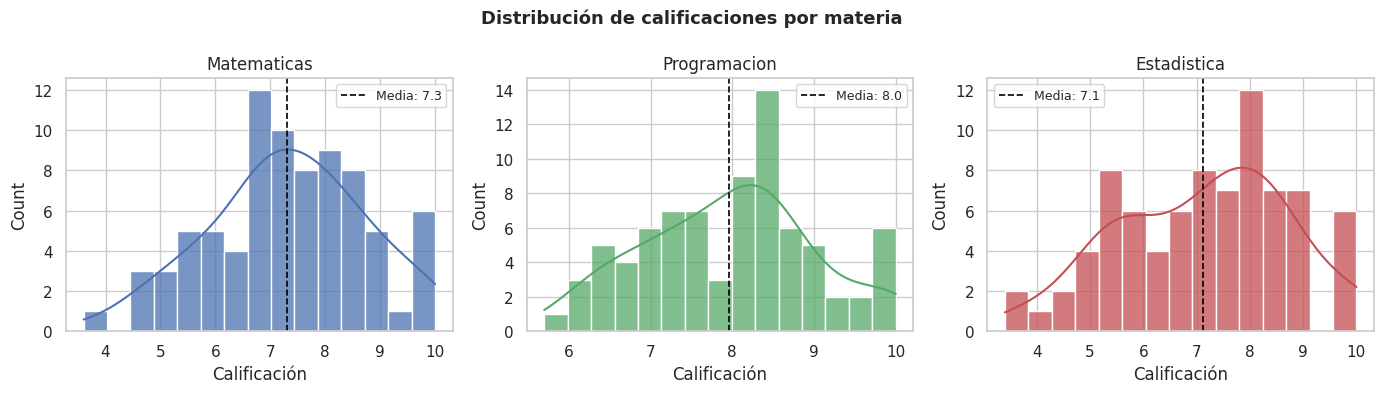

✅ Gráfica guardada


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribución de calificaciones por materia', fontsize=13, fontweight='bold')

materias = ['matematicas', 'programacion', 'estadistica']
colores  = ['#4C72B0', '#55A868', '#C44E52']

for ax, materia, color in zip(axes, materias, colores):
    sns.histplot(df[materia], bins=15, kde=True, color=color, ax=ax, alpha=0.75)
    ax.axvline(df[materia].mean(), color='black', linestyle='--', linewidth=1.2, label=f'Media: {df[materia].mean():.1f}')
    ax.set_title(materia.capitalize())
    ax.set_xlabel('Calificación')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('distribucion_calificaciones.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada')

/tmp/ipykernel_62/105617528.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='grupo', y='promedio', palette='Set2', ax=axes[0])


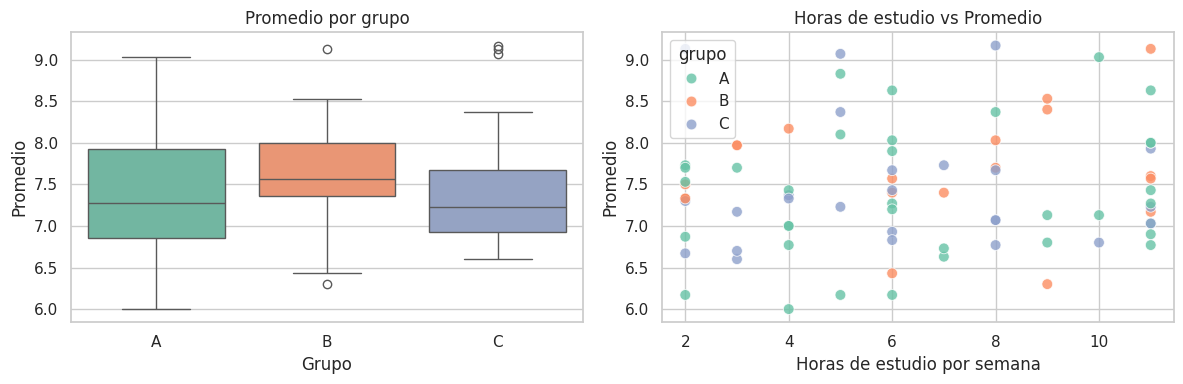

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot por grupo
sns.boxplot(data=df, x='grupo', y='promedio', palette='Set2', ax=axes[0])
axes[0].set_title('Promedio por grupo')
axes[0].set_xlabel('Grupo')
axes[0].set_ylabel('Promedio')

# Dispersión horas_estudio vs promedio
sns.scatterplot(data=df, x='horas_estudio', y='promedio', hue='grupo',
                palette='Set2', alpha=0.8, s=60, ax=axes[1])
axes[1].set_title('Horas de estudio vs Promedio')
axes[1].set_xlabel('Horas de estudio por semana')
axes[1].set_ylabel('Promedio')

plt.tight_layout()
plt.savefig('analisis_grupos.png', dpi=120, bbox_inches='tight')
plt.show()

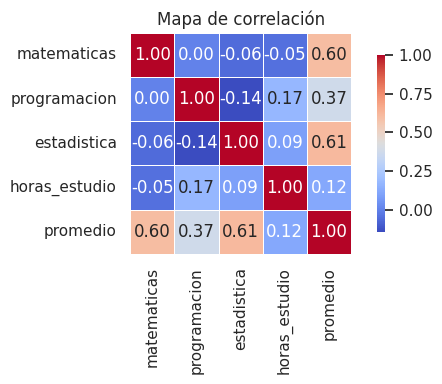

In [8]:
# Mapa de correlación
plt.figure(figsize=(6, 4))
cols_num = ['matematicas', 'programacion', 'estadistica', 'horas_estudio', 'promedio']
corr = df[cols_num].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Mapa de correlación', fontsize=12)
plt.tight_layout()
plt.savefig('correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Resumen de hallazgos

| Hallazgo | Valor |
|---|---|
| Estudiante con mayor promedio | `df.nlargest(1, 'promedio')` |
| Materia con mejor media | Programación |
| Correlación horas–promedio | Positiva moderada |

In [9]:
print('📊 Resumen del análisis:')
print(f"   Mejor promedio general : {df['promedio'].max():.2f} ({df.loc[df['promedio'].idxmax(), 'nombre']})")
print(f"   Materia con mejor media: {df[materias].mean().idxmax().capitalize()} ({df[materias].mean().max():.2f})")
print(f"   Materia con menor media: {df[materias].mean().idxmin().capitalize()} ({df[materias].mean().min():.2f})")
corr_he = df['horas_estudio'].corr(df['promedio'])
print(f"   Correlación horas/prom. : {corr_he:.3f} ({'positiva' if corr_he > 0 else 'negativa'})")

📊 Resumen del análisis:
   Mejor promedio general : 9.17 (Estudiante_7)
   Materia con mejor media: Programacion (7.96)
   Materia con menor media: Estadistica (7.12)
   Correlación horas/prom. : 0.118 (positiva)


---
**Actividad 1.3 completada ✅** — Entorno configurado, datos cargados, visualizaciones generadas.